In [1]:
import pandas as pd
import numpy as np

import tubesml as tml

import matplotlib.pyplot as plt
%matplotlib inline

from source.aggregated_stats import process_details, full_stats
from source.add_info import add_seed
from source.make_train_test import make_teams_target, make_training_data


In [3]:
men_reg = pd.read_csv('data/march-machine-learning-mania-2026/MRegularSeasonDetailedResults.csv')
men_reg = process_details(men_reg)
men_reg = full_stats(men_reg)
men_reg = add_seed('data/march-machine-learning-mania-2026/MNCAATourneySeeds.csv', men_reg)
men_target_data = pd.read_csv('data/march-machine-learning-mania-2026/MNCAATourneyCompactResults.csv')
men_target_data = make_teams_target(men_target_data, "men")
men_training = make_training_data(men_reg, men_target_data)
men_training  = men_training[men_training.DayNum >= 136]  # remove pre tourney 
men_training["tourney"] = 1

women_reg = pd.read_csv('data/march-machine-learning-mania-2026/WRegularSeasonDetailedResults.csv')
women_reg = process_details(women_reg)
women_reg = full_stats(women_reg)
women_reg = add_seed('data/march-machine-learning-mania-2026/WNCAATourneySeeds.csv', women_reg)
women_target_data = pd.read_csv('data/march-machine-learning-mania-2026/WNCAATourneyCompactResults.csv')
women_target_data = make_teams_target(women_target_data, "women")
women_training = make_training_data(women_reg, women_target_data)
women_training  = women_training[women_training.DayNum >= 136]  # remove pre tourney 
women_training["tourney"] = 0

full_training = pd.concat([men_training, women_training], ignore_index=True)


full_training.head()

,Season,DayNum,Team1,Team2,target,target_points,T1_Loc,T2_Loc,ID,T1_Ast,...,delta_FGM_no_ast_perc,delta_True_shooting_perc,delta_Opp_True_shooting_perc,delta_Eff_shooting_perc,delta_Opp_eff_shooting_perc,delta_OT_win_perc,delta_Seed,delta_off_edge,delta_def_edge,tourney
0,2003,136,1112,1436,1,29,0,0,2003_1112_1436,17.642857,...,-0.009639,0.029586,-0.024490,0.023279,-0.021080,0.500000,-15.0,15.296992,11.161959,1
1,2003,136,1113,1272,1,13,0,0,2003_1113_1272,15.551724,...,0.060936,0.023379,0.043313,0.017069,0.041206,1.000000,3.0,16.306520,6.912553,1
2,2003,136,1141,1166,1,6,0,0,2003_1141_1166,15.620690,...,-0.000726,0.024266,0.028571,0.001197,0.021989,-1.000000,5.0,17.037470,12.485948,1
3,2003,136,1143,1301,1,2,0,0,2003_1143_1301,16.000000,...,0.017620,-0.027432,-0.019602,-0.010679,-0.002899,-0.666667,-1.0,4.086544,8.747367,1
4,2003,136,1140,1163,0,-5,0,0,2003_1140_1163,13.419355,...,-0.029044,0.028961,0.038428,0.005684,0.028207,-1.000000,7.0,13.738997,12.639235,1


# Winning target

In [4]:
target = "target"
col_to_use = [c for c in full_training if "target" not in c and c != "ID" and "region" not in c] + [target]

df = full_training[col_to_use].copy()

to_drop = ["delta_def_rating_diff", "delta_impact_diff", "T1_def_rating_diff", "T2_def_rating_diff"]
df = df.drop(to_drop, axis=1)

df.sample(5)

,Season,DayNum,Team1,Team2,T1_Loc,T2_Loc,T1_Ast,T1_Ast_TO_ratio,T1_Ast_TO_ratio_diff,T1_Ast_diff,...,delta_True_shooting_perc,delta_Opp_True_shooting_perc,delta_Eff_shooting_perc,delta_Opp_eff_shooting_perc,delta_OT_win_perc,delta_Seed,delta_off_edge,delta_def_edge,tourney,target
4240,2018,137,3294,3276,0,0,15.250000,1.210498,0.507876,4.437500,...,-0.010473,0.030753,-0.014332,0.029954,0.666667,3.0,14.488152,14.425993,0,0
1449,2003,152,1266,1242,0,0,16.321429,1.289995,0.187273,3.357143,...,0.030508,0.010873,0.011429,0.001999,0.000000,1.0,25.814173,10.090817,1,0
3074,2014,141,3277,3314,0,0,16.354839,1.128487,0.206252,3.612903,...,0.003058,0.008239,0.000907,0.020081,1.000000,1.0,17.059966,15.193801,0,0
1134,2021,152,1124,1222,0,0,17.041667,1.665897,0.821344,4.666667,...,0.045369,0.048115,0.061734,0.061704,1.000000,-1.0,31.068152,20.649199,1,1
1742,2008,138,1458,1243,0,0,12.787879,1.489786,0.684095,2.757576,...,0.012330,-0.052103,0.009548,-0.049295,-0.500000,-8.0,13.278648,22.177673,1,1


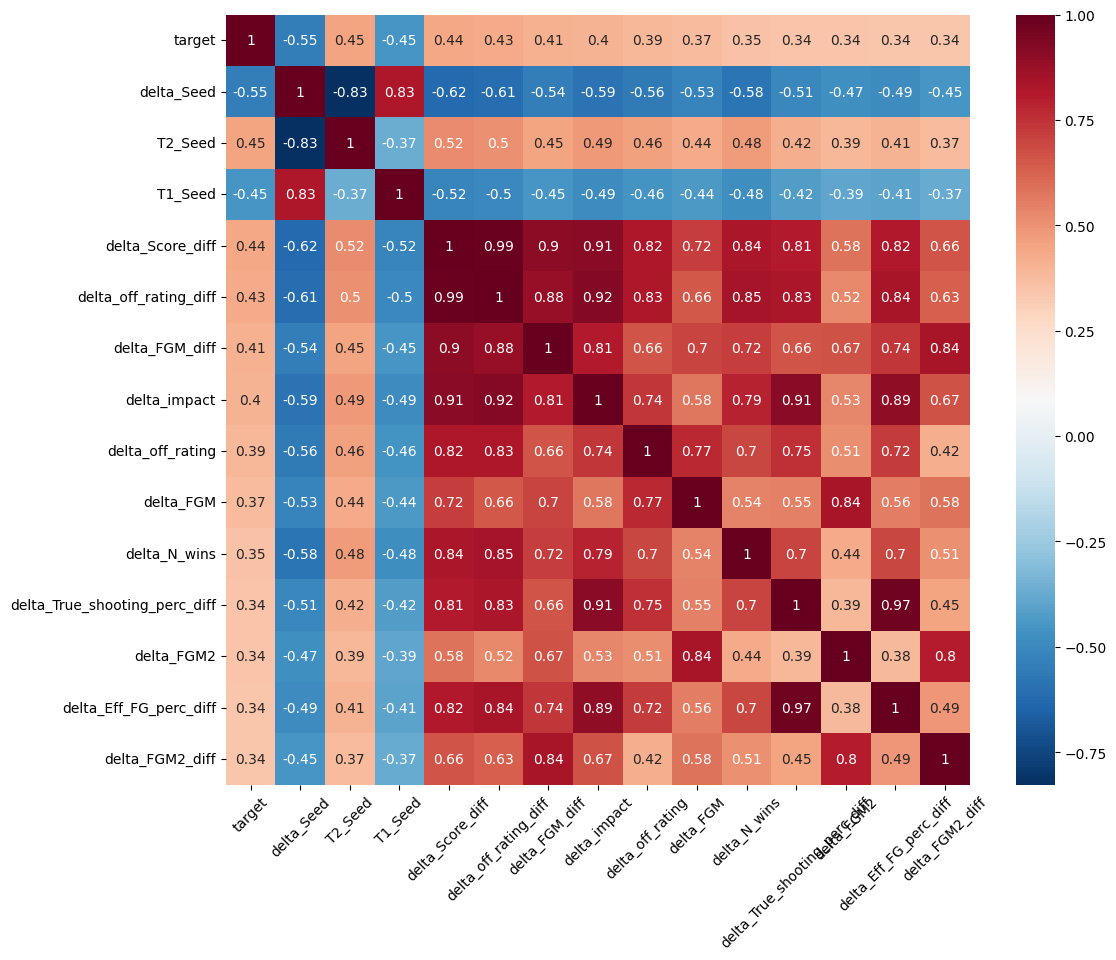

In [5]:
high_corr = tml.plot_correlations(data=df, target=target, limit=15, annot=True)

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN be

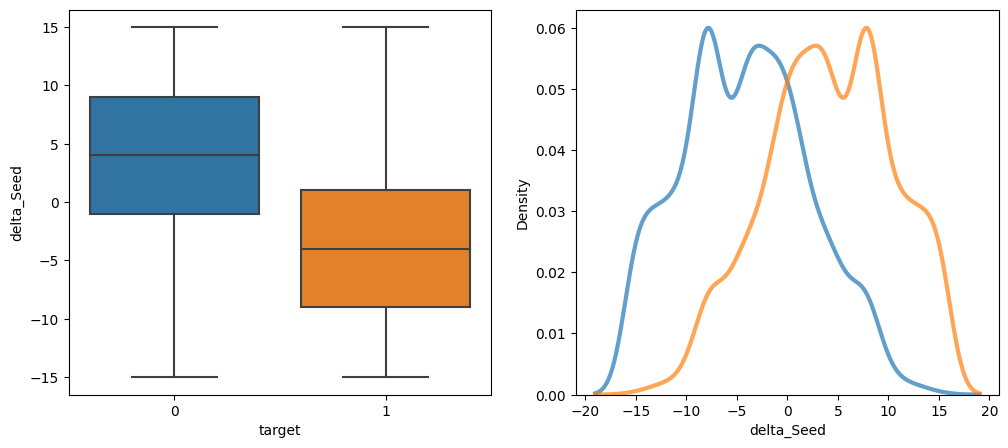

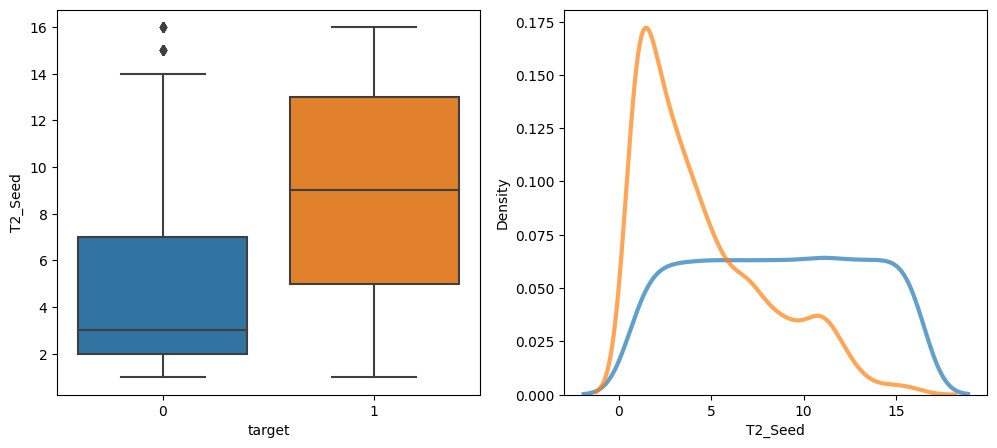

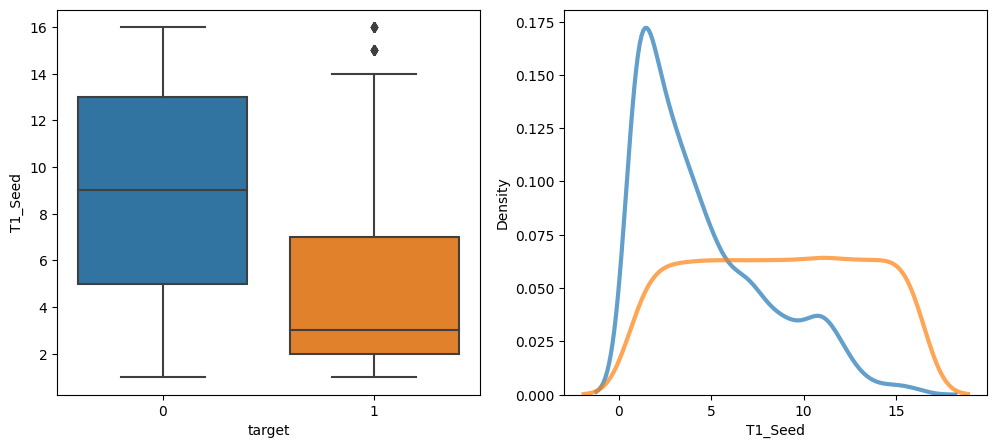

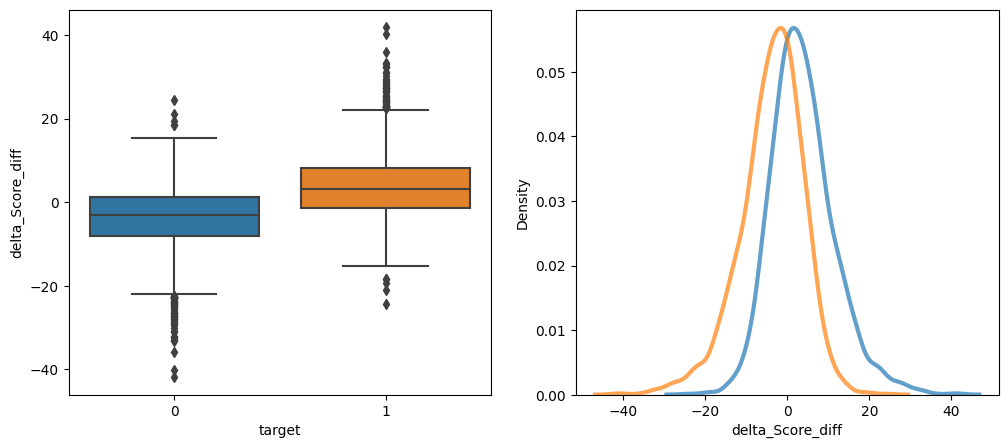

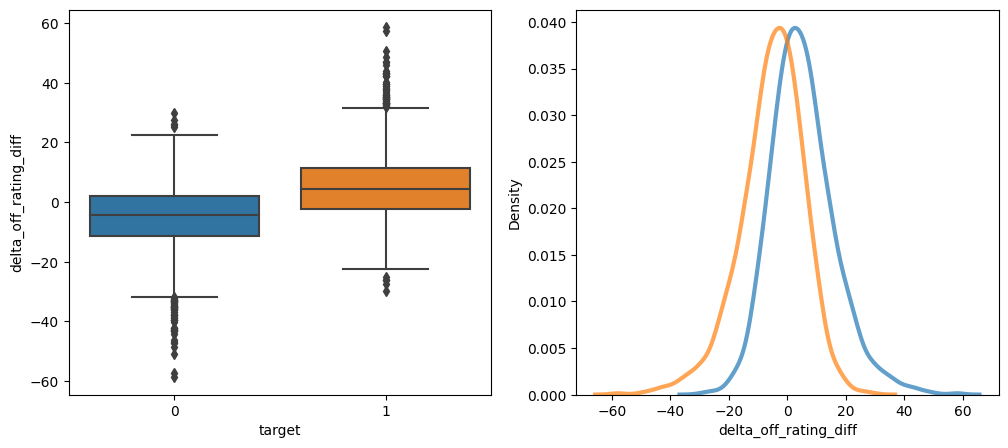

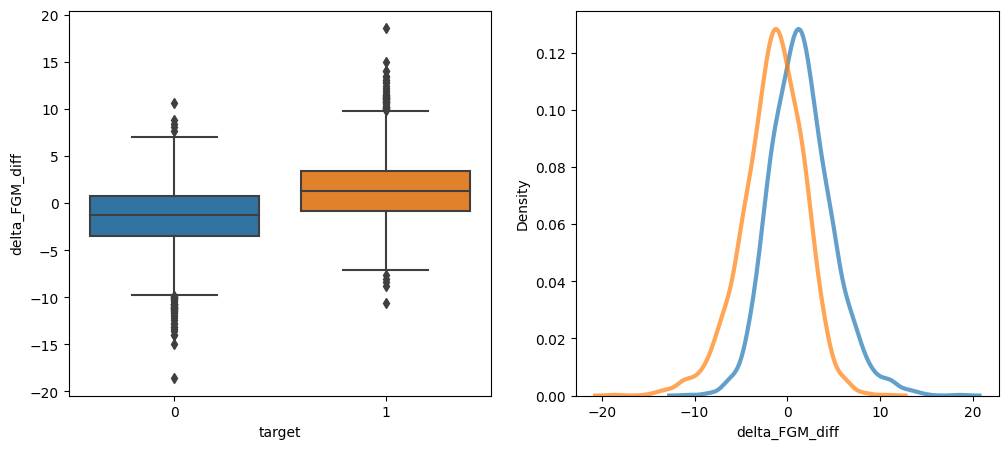

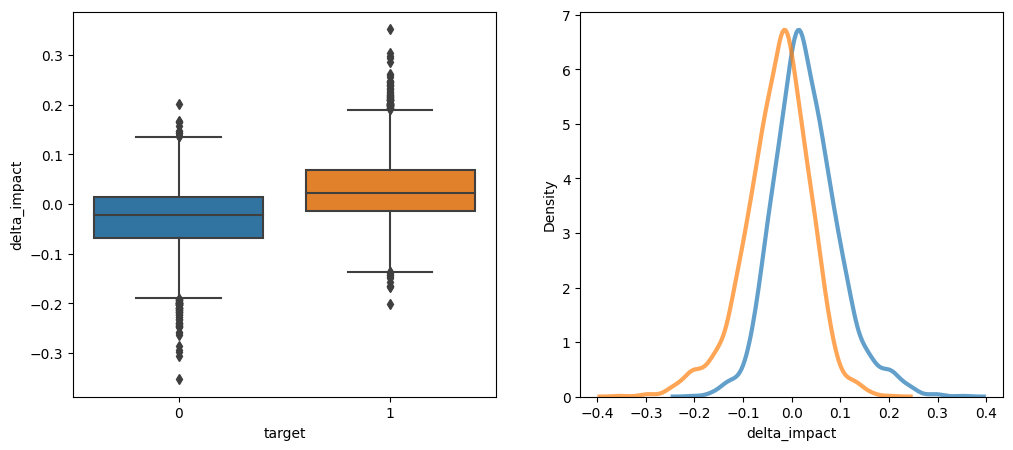

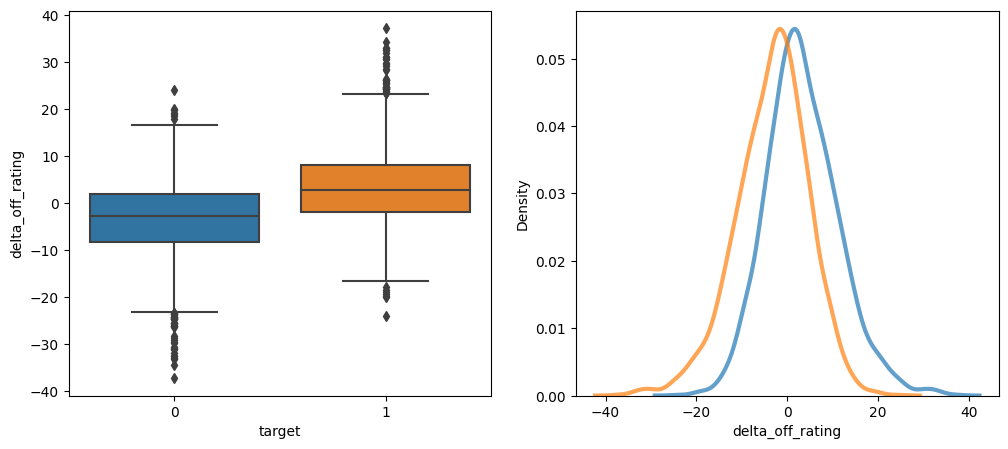

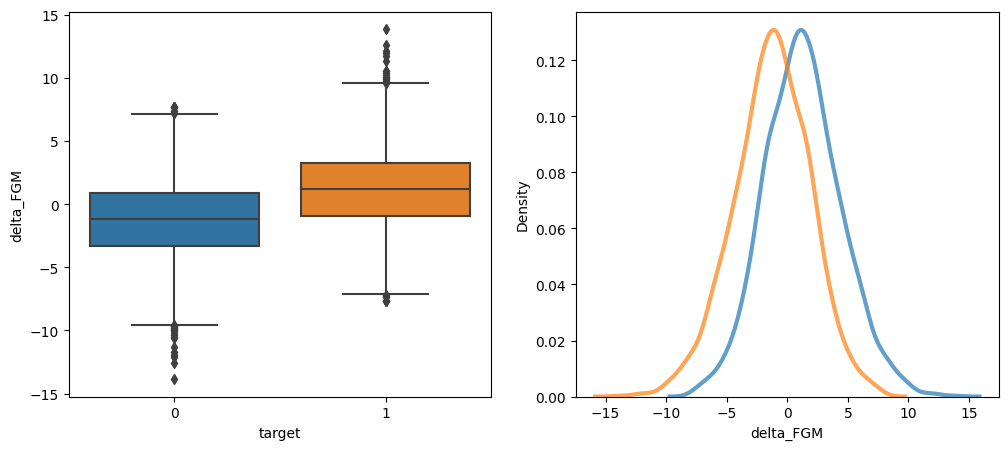

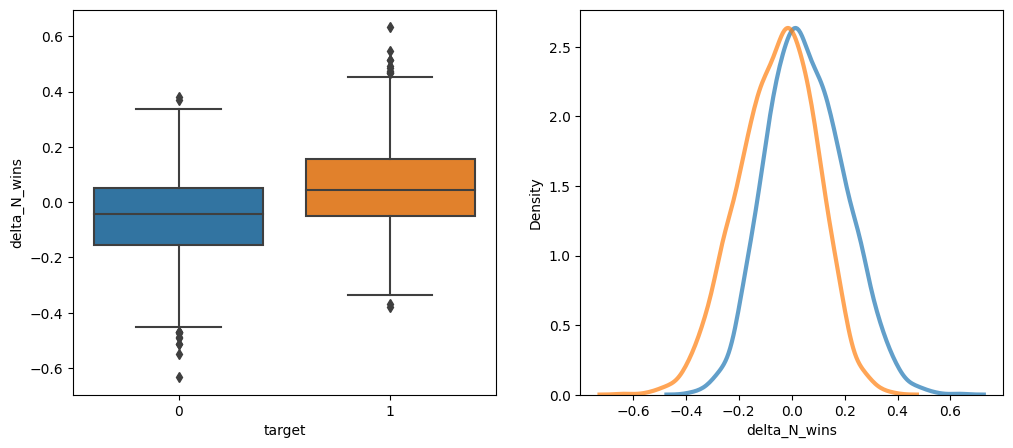

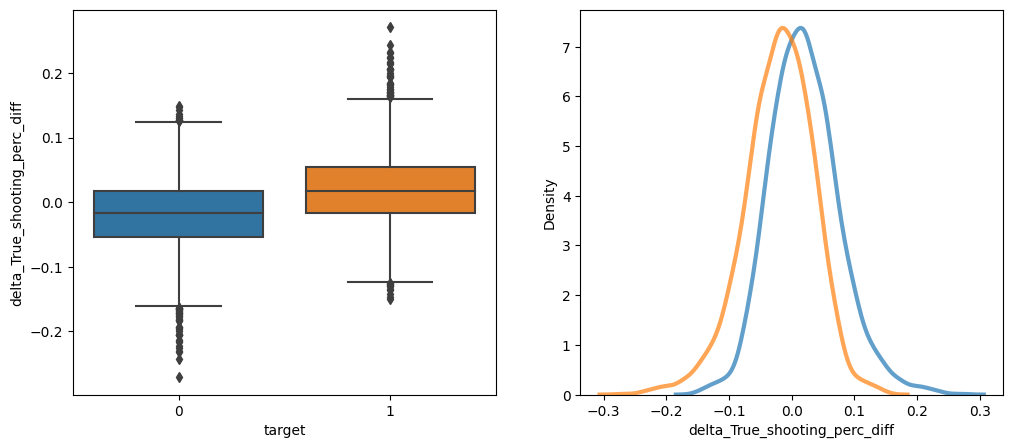

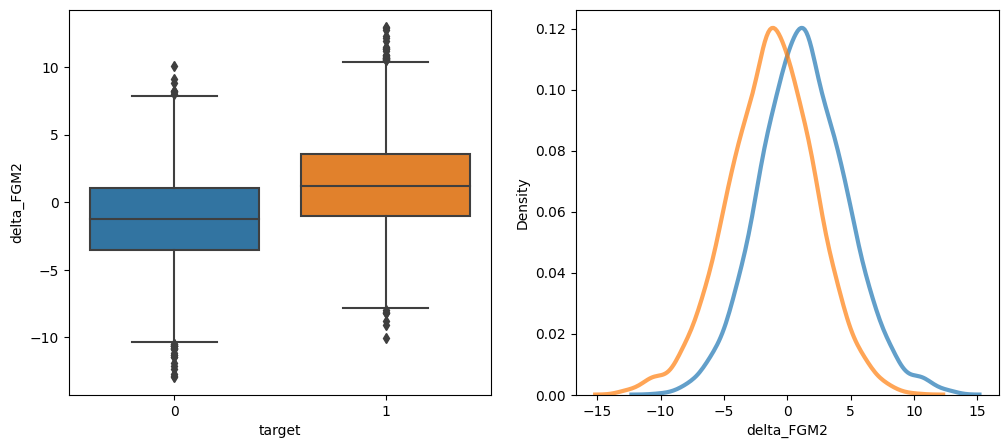

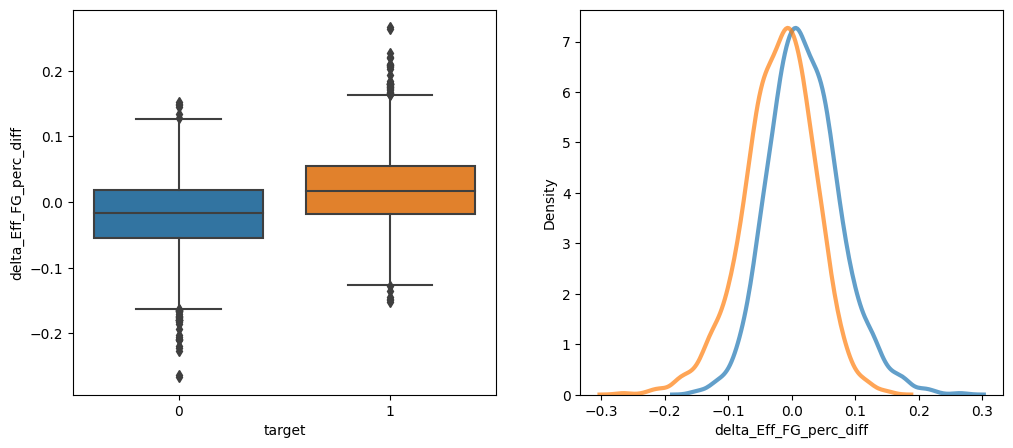

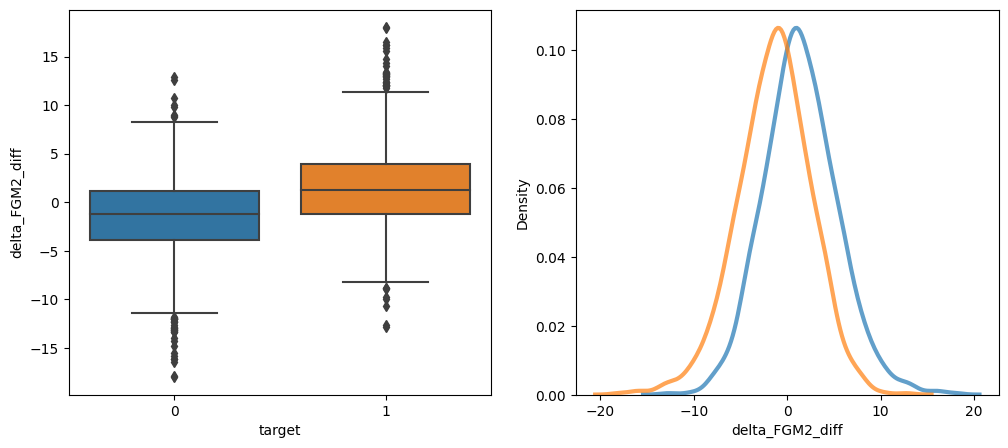

In [6]:
for col in high_corr.index:
    if col == target:
        continue
    tml.segm_target(data=df, cat=target, target=col)

# Point difference

In [7]:
target = "target_points"
col_to_use = [c for c in full_training if "target" not in c and c != "ID" and "region" not in c] + [target]

df = full_training[col_to_use].copy()
to_drop = ["delta_def_rating_diff", "delta_impact_diff", "T1_def_rating_diff", "T2_def_rating_diff"]
df = df.drop(to_drop, axis=1)

df.head()

,Season,DayNum,Team1,Team2,T1_Loc,T2_Loc,T1_Ast,T1_Ast_TO_ratio,T1_Ast_TO_ratio_diff,T1_Ast_diff,...,delta_True_shooting_perc,delta_Opp_True_shooting_perc,delta_Eff_shooting_perc,delta_Opp_eff_shooting_perc,delta_OT_win_perc,delta_Seed,delta_off_edge,delta_def_edge,tourney,target_points
0,2003,136,1112,1436,0,0,17.642857,1.293499,0.268768,2.178571,...,0.029586,-0.024490,0.023279,-0.021080,0.500000,-15.0,15.296992,11.161959,1,29
1,2003,136,1113,1272,0,0,15.551724,1.203251,0.234365,1.482759,...,0.023379,0.043313,0.017069,0.041206,1.000000,3.0,16.306520,6.912553,1,13
2,2003,136,1141,1166,0,0,15.620690,0.876120,0.085721,3.827586,...,0.024266,0.028571,0.001197,0.021989,-1.000000,5.0,17.037470,12.485948,1,6
3,2003,136,1143,1301,0,0,16.000000,1.223081,0.068821,-0.034483,...,-0.027432,-0.019602,-0.010679,-0.002899,-0.666667,-1.0,4.086544,8.747367,1,2
4,2003,136,1140,1163,0,0,13.419355,1.089313,0.287916,2.645161,...,0.028961,0.038428,0.005684,0.028207,-1.000000,7.0,13.738997,12.639235,1,-5


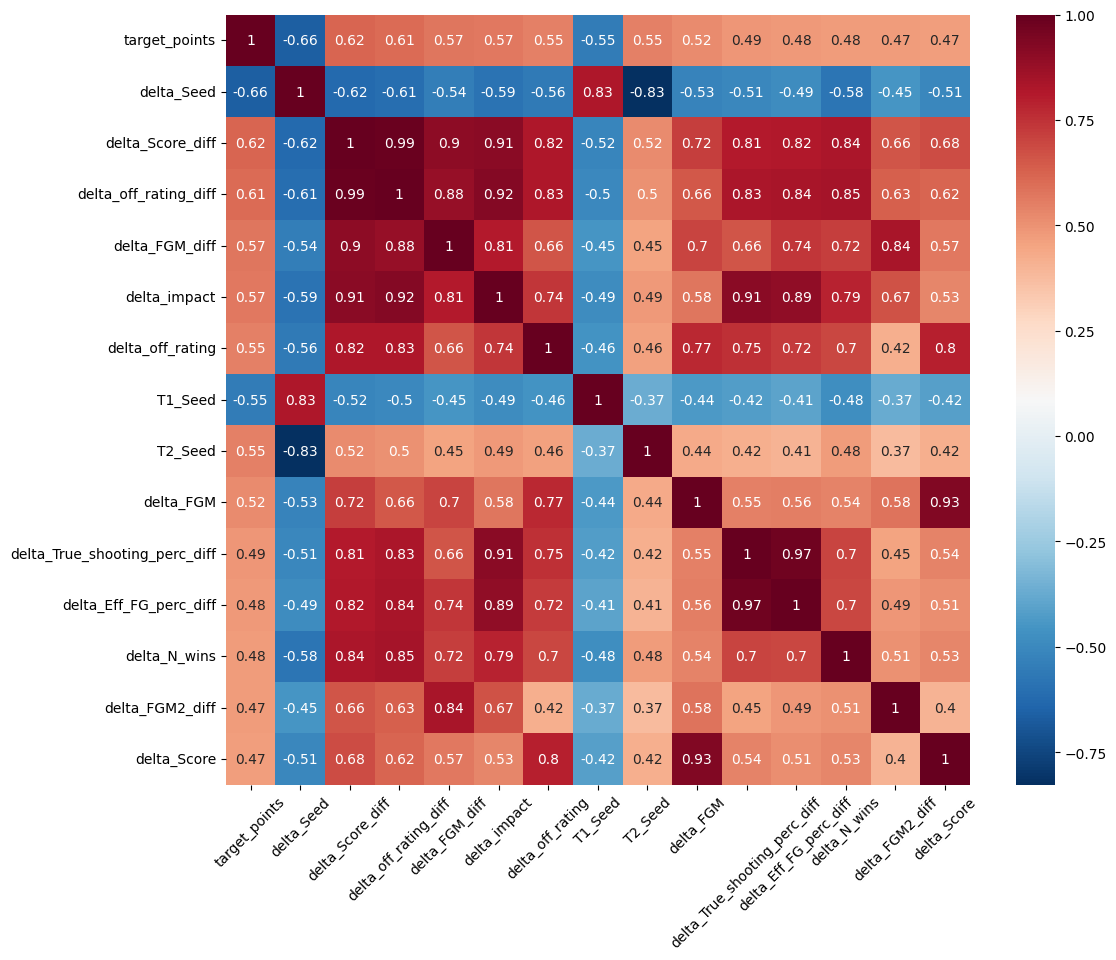

In [8]:
high_corr = tml.plot_correlations(data=df, target=target, limit=15, annot=True)

                               delta_Seed  delta_Score_diff  \
delta_Seed                       1.000000         -0.624833   
delta_Score_diff                -0.624833          1.000000   
delta_off_rating_diff           -0.608331          0.989945   
delta_FGM_diff                  -0.544874          0.904304   
delta_impact                    -0.587713          0.908747   
delta_off_rating                -0.559344          0.824967   
T1_Seed                          0.827021         -0.516750   
T2_Seed                         -0.827021          0.516750   
delta_FGM                       -0.526988          0.719722   
delta_True_shooting_perc_diff   -0.508980          0.813077   
delta_Eff_FG_perc_diff          -0.490761          0.817225   
delta_N_wins                    -0.577771          0.835514   
delta_FGM2_diff                 -0.450218          0.663003   
delta_Score                     -0.506195          0.683111   
target_points                   -0.664030          0.61

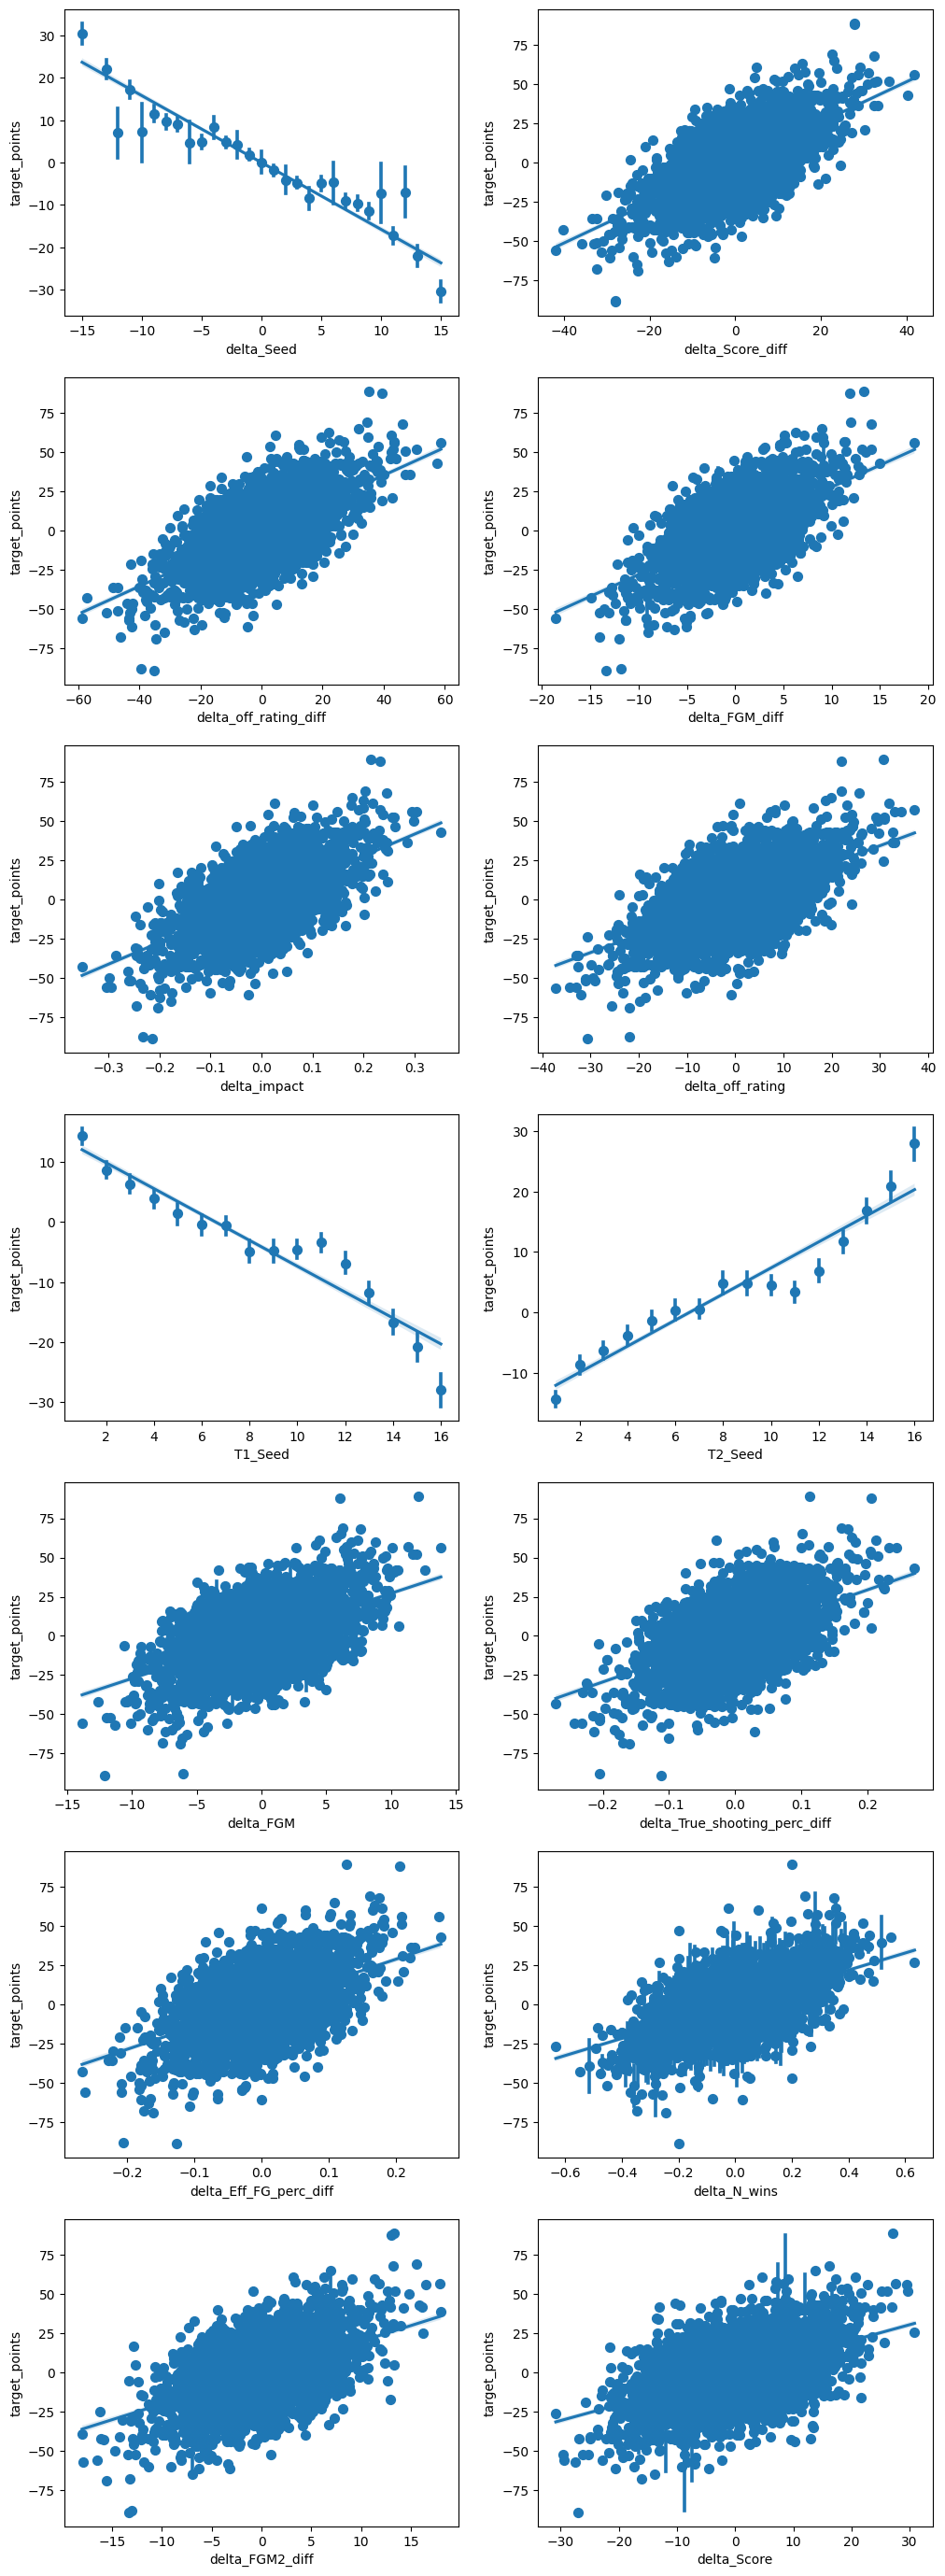

In [9]:
tml.corr_target(data=df, target=target, cols=[c for c in high_corr.index if c != target], x_estimator=np.mean)